In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [3]:
# load the data from the file

# Path: Duong dan chua file dataset
path ='C:\\Users\\sony\\Desktop\\slide_ML\\slide_buoi_4_LogisticReg\\marks.csv'   # thay doi duong dan thich hop
data = pd.read_csv(path, header=None)
print(data)

            0          1  2
0   34.623660  78.024693  0
1   30.286711  43.894998  0
2   35.847409  72.902198  0
3   60.182599  86.308552  1
4   79.032736  75.344376  1
5   45.083277  56.316372  0
6   61.106665  96.511426  1
7   75.024746  46.554014  1
8   76.098787  87.420570  1
9   84.432820  43.533393  1
10  95.861555  38.225278  0
11  75.013658  30.603263  0
12  82.307053  76.481963  1
13  69.364589  97.718692  1
14  39.538339  76.036811  0
15  53.971052  89.207350  1
16  69.070144  52.740470  1
17  67.946855  46.678574  0
18  70.661510  92.927138  1
19  76.978784  47.575964  1
20  67.372028  42.838438  0
21  89.676776  65.799366  1
22  50.534788  48.855812  0
23  34.212061  44.209529  0
24  77.924091  68.972360  1
25  62.271014  69.954458  1
26  80.190181  44.821629  1
27  93.114389  38.800670  0
28  61.830206  50.256108  0
29  38.785804  64.995681  0
..        ...        ... ..
70  32.722833  43.307173  0
71  64.039320  78.031688  1
72  72.346494  96.227593  1
73  60.457886  73.09

In [4]:
 # X = feature values, all the columns except the last column
X = data.iloc[:, :-1]
print(X.shape)

# y = target values, last column of the data frame
y = data.iloc[:, -1]
print(y.shape)

# filter out the applicants that got admitted
admitted = data.loc[y == 1]

# filter out the applicants that din't get admission
not_admitted = data.loc[y == 0]


(100, 2)
(100,)


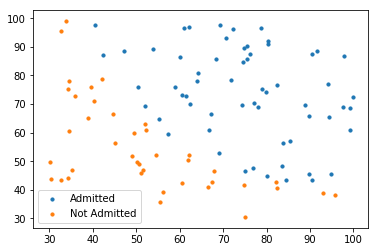

In [5]:
# plots
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1], s=10, label='Admitted')
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1], s=10,label='Not Admitted')
plt.legend(['Admitted','Not Admitted'])


In [13]:
# preparing the data for building the model
X_new = np.c_[np.ones((X.shape[0], 1)), X] # them mot dau tien tat ca gia tri la 1
print(X_new.shape)
y_new = y[:, np.newaxis]
print(y.shape)


(100, 3)
(100,)


In [14]:
# Using scikit-learn
model = LogisticRegression(fit_intercept=False)  # False for calculating the bias
model.fit(X_new, y_new)
parameters = model.coef_
predicted_classes = model.predict(X_new)
accuracy = accuracy_score(y_new.flatten(),predicted_classes)
print('The accuracy score using scikit-learn is {}'.format(accuracy))
print("The model parameters using scikit learn")
print(parameters)
print("confusion_matrix")
print(confusion_matrix(predicted_classes,y_new))

The accuracy score using scikit-learn is 0.87
The model parameters using scikit learn
[[-3.89977794  0.03844482  0.03101855]]
confusion_matrix
[[27  0]
 [13 60]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


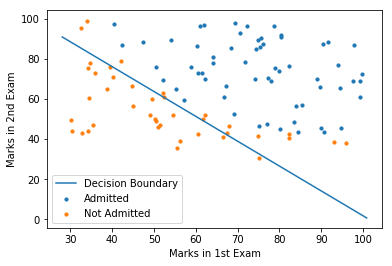

In [15]:
# plotting the decision boundary
# As there are two features
# wo + w1x1 + w2x2 = 0
# x2 = - (wo + w1x1)/(w2)

x_values = [np.min(X_new[:, 1] - 2), np.max(X_new[:, 2] + 2)]
y_values = -(parameters[0][0] + np.dot(parameters[0][1], x_values)) / parameters[0][2]

# plots
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1], s=10, label='Admitted')
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1], s=10,label='Not Admitted')
plt.legend(['Admitted','Not Admitted'])
plt.plot(x_values, y_values, label='Decision Boundary')
plt.xlabel('Marks in 1st Exam')
plt.ylabel('Marks in 2nd Exam')
plt.legend()
plt.show()

In [28]:
# slipt train data and test data
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_new, y_new, test_size = 0.2, random_state=0)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(80, 3)
(20, 3)
(80, 1)
(20, 1)


(48, 3)
(32, 3)


Text(0.5, 1.0, 'Trainning data')

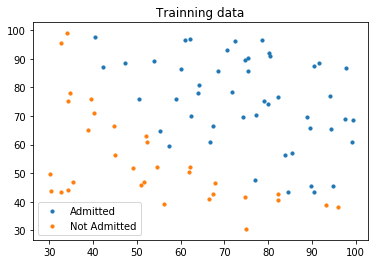

In [29]:
Train_admit = X_train[(Y_train[:]==1).flatten()]
print(Train_admit.shape)
Train_nonadmit = X_train[(Y_train[:]==0).flatten()]
print(Train_nonadmit.shape)
plt.scatter(Train_admit[:, 1], Train_admit[:, 2], s=10,label='Admitted')
plt.scatter(Train_nonadmit[:, 1], Train_nonadmit[:, 2], s=10,label='Not Admitted')
plt.legend()
plt.title("Trainning data")
# plt.legend(['Admitted','Not Admitted'])

In [30]:
model2 = LogisticRegression(fit_intercept=False)
model2.fit(X_train, Y_train)
parameters = model2.coef_
predicted_classes = model2.predict(X_test)
accuracy = accuracy_score(predicted_classes,Y_test)
print('The accuracy score using scikit-learn is {}'.format(accuracy))
print("The model parameters using scikit learn")
print(parameters)
print("confusion_matrix")
print(confusion_matrix(predicted_classes,Y_test))

The accuracy score using scikit-learn is 0.95
The model parameters using scikit learn
[[-3.4294559   0.03032132  0.03124498]]
confusion_matrix
[[ 7  0]
 [ 1 12]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


(12, 3)
(8, 3)


Text(0.5, 1.0, 'test data')

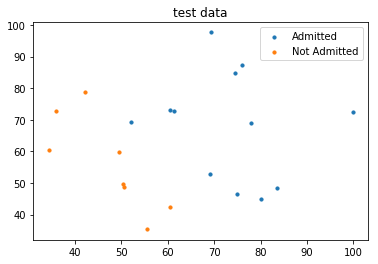

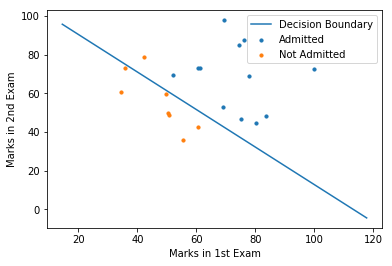

In [32]:
plt.scatter(Test_admit[:, 1], Test_admit[:, 2], s=10,label='Admitted')
plt.scatter(Test_nonadmit[:, 1], Test_nonadmit[:, 2], s=10,label='Not Admitted')
plt.legend()
x_values = [np.min(X_test[:, 1] - 20), np.max(X_test[:, 2] + 20)]
y_values = -(parameters[0][0] + np.dot(parameters[0][1], x_values)) / parameters[0][2]
# plots
plt.plot(x_values, y_values, label='Decision Boundary')
plt.xlabel('Marks in 1st Exam')
plt.ylabel('Marks in 2nd Exam')
plt.legend()
plt.show()
